In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
import sqlite3
import warnings
warnings.filterwarnings('ignore')

# Connect to your actual DB
conn = sqlite3.connect(r"C:\Users\ASUS\Desktop\Mutual Fund Analytics\bluestock_mf.db")

# Check what tables exist
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

                      name
0          sqlite_sequence
1                 dim_date
2                 dim_fund
3                 fact_nav
4        fact_transactions
5         fact_performance
6                 fact_aum
7  fact_portfolio_holdings
8           fact_benchmark


In [5]:
# Adjust table name after checking Step 0 output
nav_df = pd.read_sql("""
    SELECT date, scheme_code, scheme_name, nav
    FROM nav_history         -- change this if table name differs
    ORDER BY scheme_name, date
""", conn, parse_dates=["date"])

print(nav_df.shape)
print(nav_df["scheme_name"].nunique(), "schemes found")
print(nav_df.head())

DatabaseError: Execution failed on sql '
    SELECT date, scheme_code, scheme_name, nav
    FROM nav_history         -- change this if table name differs
    ORDER BY scheme_name, date
': no such table: nav_history

In [6]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

                      name
0          sqlite_sequence
1                 dim_date
2                 dim_fund
3                 fact_nav
4        fact_transactions
5         fact_performance
6                 fact_aum
7  fact_portfolio_holdings
8           fact_benchmark


In [7]:
for table in tables['name']:
    print(f"\n--- {table} ---")
    info = pd.read_sql(f"PRAGMA table_info({table})", conn)
    print(info[['name','type']].to_string())


--- sqlite_sequence ---
   name type
0  name     
1   seq     

--- dim_date ---
         name     type
0     date_id  INTEGER
1        date     TEXT
2        year  INTEGER
3       month  INTEGER
4     quarter  INTEGER
5         day  INTEGER
6  is_weekend  INTEGER

--- dim_fund ---
                  name    type
0            amfi_code  BIGINT
1           fund_house    TEXT
2          scheme_name    TEXT
3             category    TEXT
4         sub_category    TEXT
5                 plan    TEXT
6          launch_date    TEXT
7            benchmark    TEXT
8    expense_ratio_pct   FLOAT
9        exit_load_pct   FLOAT
10      min_sip_amount  BIGINT
11  min_lumpsum_amount  BIGINT
12        fund_manager    TEXT
13       risk_category    TEXT
14  sebi_category_code    TEXT

--- fact_nav ---
        name    type
0  amfi_code  BIGINT
1       date    TEXT
2        nav   FLOAT

--- fact_transactions ---
                  name    type
0          investor_id    TEXT
1     transaction_date    TEX

In [8]:
print(tables['name'].tolist())

['sqlite_sequence', 'dim_date', 'dim_fund', 'fact_nav', 'fact_transactions', 'fact_performance', 'fact_aum', 'fact_portfolio_holdings', 'fact_benchmark']


In [9]:
for t in ['fact_nav', 'dim_fund', 'fact_benchmark', 'fact_performance']:
    print(f"\n--- {t} ---")
    info = pd.read_sql(f"PRAGMA table_info({t})", conn)
    print(info[['name','type']].to_string())


--- fact_nav ---
        name    type
0  amfi_code  BIGINT
1       date    TEXT
2        nav   FLOAT

--- dim_fund ---
                  name    type
0            amfi_code  BIGINT
1           fund_house    TEXT
2          scheme_name    TEXT
3             category    TEXT
4         sub_category    TEXT
5                 plan    TEXT
6          launch_date    TEXT
7            benchmark    TEXT
8    expense_ratio_pct   FLOAT
9        exit_load_pct   FLOAT
10      min_sip_amount  BIGINT
11  min_lumpsum_amount  BIGINT
12        fund_manager    TEXT
13       risk_category    TEXT
14  sebi_category_code    TEXT

--- fact_benchmark ---
          name   type
0         date   TEXT
1   index_name   TEXT
2  close_value  FLOAT

--- fact_performance ---
                  name    type
0            amfi_code  BIGINT
1          scheme_name    TEXT
2           fund_house    TEXT
3             category    TEXT
4                 plan    TEXT
5       return_1yr_pct   FLOAT
6       return_3yr_pct   FLOA

In [10]:
# NAV data with fund names (join fact_nav + dim_fund)
nav_df = pd.read_sql("""
    SELECT n.date, n.amfi_code, n.nav,
           f.scheme_name, f.category, f.expense_ratio_pct
    FROM fact_nav n
    JOIN dim_fund f ON n.amfi_code = f.amfi_code
    ORDER BY f.scheme_name, n.date
""", conn, parse_dates=["date"])

print(nav_df.shape)
print(nav_df.head())

(46000, 6)
        date  amfi_code       nav  \
0 2022-01-03     101206  305.0996   
1 2022-01-04     101206  305.4514   
2 2022-01-05     101206  306.6324   
3 2022-01-06     101206  305.9800   
4 2022-01-07     101206  304.0480   

                                     scheme_name category  expense_ratio_pct  
0  ABSL Frontline Equity Fund - Regular - Growth   Equity                1.6  
1  ABSL Frontline Equity Fund - Regular - Growth   Equity                1.6  
2  ABSL Frontline Equity Fund - Regular - Growth   Equity                1.6  
3  ABSL Frontline Equity Fund - Regular - Growth   Equity                1.6  
4  ABSL Frontline Equity Fund - Regular - Growth   Equity                1.6  


In [11]:
bench_df = pd.read_sql("""
    SELECT * FROM fact_benchmark
""", conn, parse_dates=["date"])

print(bench_df.head())
print(bench_df["index_name"].unique())  # see exact index names

        date    index_name  close_value
0 2022-01-03  BSE_SMALLCAP     26554.60
1 2022-01-04  BSE_SMALLCAP     27079.92
2 2022-01-05  BSE_SMALLCAP     27313.35
3 2022-01-06  BSE_SMALLCAP     27377.05
4 2022-01-07  BSE_SMALLCAP     26316.86
<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str


In [12]:
nav_wide = nav_df.pivot_table(
    index="date", columns="scheme_name", values="nav"
).sort_index()

fund_names = nav_wide.columns.tolist()
funds_meta = nav_df[["scheme_name","category","expense_ratio_pct"]]\
             .drop_duplicates().set_index("scheme_name")

print(f"Funds: {len(fund_names)} | Days: {len(nav_wide)}")

Funds: 40 | Days: 1150


In [13]:
daily_ret = nav_wide.pct_change().dropna()

desc = daily_ret.describe().T
print(desc[["mean","std","min","max"]].round(4))

assert (desc["std"] < 0.04).all(), "Unusual volatility"
assert (desc["mean"].abs() < 0.005).all(), "Extreme mean"
print("✅ Distribution looks reasonable")

                                                      mean     std     min  \
scheme_name                                                                  
ABSL Frontline Equity Fund - Regular - Growth       0.0009  0.0092 -0.0381   
ABSL Liquid Fund - Regular - Growth                 0.0002  0.0003 -0.0008   
ABSL Small Cap Fund - Regular - Growth              0.0004  0.0163 -0.0518   
Axis Bluechip Fund - Direct - Growth                0.0003  0.0088 -0.0295   
Axis Bluechip Fund - Regular - Growth               0.0003  0.0088 -0.0234   
Axis Midcap Fund - Regular - Growth                 0.0010  0.0122 -0.0408   
Axis Small Cap Fund - Regular - Growth              0.0002  0.0158 -0.0484   
DSP Midcap Fund - Regular - Growth                  0.0011  0.0112 -0.0301   
DSP Small Cap Fund - Regular - Growth               0.0012  0.0156 -0.0489   
DSP Top 100 Equity Fund - Regular - Growth          0.0005  0.0090 -0.0367   
HDFC Mid-Cap Opportunities Fund - Direct - Growth   0.0005  0.01

In [14]:
end_date = nav_wide.index[-1]

def calc_cagr(series, years):
    start = end_date - pd.DateOffset(years=years)
    sub = series.loc[series.index >= start].dropna()
    if len(sub) < 20:
        return np.nan
    return (sub.iloc[-1] / sub.iloc[0]) ** (1/years) - 1

cagr_df = pd.DataFrame({
    f: {
        "CAGR_1yr": calc_cagr(nav_wide[f], 1),
        "CAGR_3yr": calc_cagr(nav_wide[f], 3),
        "CAGR_5yr": calc_cagr(nav_wide[f], 5),
    }
    for f in fund_names
}).T
cagr_df.index.name = "Fund"

display((cagr_df * 100).round(2).sort_values("CAGR_3yr", ascending=False))

,CAGR_1yr,CAGR_3yr,CAGR_5yr
Fund,,,
Axis Midcap Fund - Regular - Growth,22.26,35.11,24.45
Mirae Asset Large Cap Fund - Regular - Growth,20.36,34.00,26.80
ICICI Pru Bluechip Fund - Direct - Growth,13.06,32.49,20.23
HDFC Mid-Cap Opportunities Fund - Regular - Growth,53.23,32.44,26.07
ICICI Pru Midcap Fund - Regular - Growth,29.60,31.78,28.38
SBI Bluechip Fund - Regular Plan - Growth,60.44,30.46,22.38
Kotak Flexicap Fund - Regular - Growth,26.66,29.58,26.74
Mirae Asset Tax Saver Fund - Regular - Growth,39.75,29.18,27.63
ABSL Frontline Equity Fund - Regular - Growth,47.92,28.97,20.44


In [15]:
RF = 0.065

sharpe = {}
for f in fund_names:
    r = daily_ret[f].dropna()
    sharpe[f] = ((r - RF/252).mean() / r.std()) * np.sqrt(252)

sharpe_s = pd.Series(sharpe, name="Sharpe").sort_values(ascending=False)
display(sharpe_s.reset_index().rename(columns={"index":"Fund"}))

,Fund,Sharpe
0,Mirae Asset Large Cap Fund - Regular - Growth,1.448291
1,Kotak Flexicap Fund - Regular - Growth,1.306744
2,Mirae Asset Tax Saver Fund - Regular - Growth,1.234930
3,SBI Bluechip Fund - Regular Plan - Growth,1.208267
4,ICICI Pru Midcap Fund - Regular - Growth,1.180101
5,DSP Midcap Fund - Regular - Growth,1.132122
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.093699
7,Nippon India Large Cap Fund - Regular - Growth,1.081659
8,ABSL Frontline Equity Fund - Regular - Growth,1.027213
9,ICICI Pru Bluechip Fund - Direct - Growth,1.026524


In [16]:
sortino = {}
for f in fund_names:
    r = daily_ret[f].dropna()
    ann_excess = (r.mean() - RF/252) * 252
    downside_std = r[r < 0].std() * np.sqrt(252)
    sortino[f] = ann_excess / downside_std if downside_std > 0 else np.nan

sortino_s = pd.Series(sortino, name="Sortino").sort_values(ascending=False)

display(pd.DataFrame({
    "Sharpe": sharpe_s,
    "Sortino": sortino_s
}).head(15).round(4))

,Sharpe,Sortino
ABSL Frontline Equity Fund - Regular - Growth,1.0272,1.7996
ABSL Liquid Fund - Regular - Growth,-0.8156,-1.6810
ABSL Small Cap Fund - Regular - Growth,0.1627,0.2766
Axis Bluechip Fund - Direct - Growth,0.1296,0.2211
Axis Bluechip Fund - Regular - Growth,0.0308,0.0526
Axis Midcap Fund - Regular - Growth,0.9982,1.7038
Axis Small Cap Fund - Regular - Growth,-0.0760,-0.1282
DSP Midcap Fund - Regular - Growth,1.1321,1.8751
DSP Small Cap Fund - Regular - Growth,0.9498,1.6198
DSP Top 100 Equity Fund - Regular - Growth,0.4640,0.7621


In [17]:
# Get Nifty 100 from benchmark
# First check exact name from Cell 2 output
nifty100 = bench_df[bench_df["index_name"] == "Nifty 100"]\
           .set_index("date")["close_value"].sort_index()

bench_ret = nifty100.pct_change().dropna()

alpha_beta = {}
for f in fund_names:
    fr = daily_ret[f].dropna()
    idx = fr.index.intersection(bench_ret.index)
    if len(idx) < 100:
        alpha_beta[f] = {"Beta": np.nan, "Alpha_annualised": np.nan, "R_squared": np.nan}
        continue
    slope, intercept, r, p, se = stats.linregress(
        bench_ret.loc[idx], fr.loc[idx]
    )
    alpha_beta[f] = {
        "Beta": round(slope, 4),
        "Alpha_annualised": round(intercept * 252, 4),
        "R_squared": round(r**2, 4),
    }

ab_df = pd.DataFrame(alpha_beta).T
ab_df.index.name = "Fund"

# Save
ab_df.to_csv(r"C:\Users\ASUS\Desktop\Mutual Fund Analytics\data\alpha_beta.csv")
display(ab_df.sort_values("Alpha_annualised", ascending=False))

,Beta,Alpha_annualised,R_squared
Fund,,,
ABSL Frontline Equity Fund - Regular - Growth,NaN,NaN,NaN
ABSL Liquid Fund - Regular - Growth,NaN,NaN,NaN
ABSL Small Cap Fund - Regular - Growth,NaN,NaN,NaN
Axis Bluechip Fund - Direct - Growth,NaN,NaN,NaN
Axis Bluechip Fund - Regular - Growth,NaN,NaN,NaN
Axis Midcap Fund - Regular - Growth,NaN,NaN,NaN
Axis Small Cap Fund - Regular - Growth,NaN,NaN,NaN
DSP Midcap Fund - Regular - Growth,NaN,NaN,NaN
DSP Small Cap Fund - Regular - Growth,NaN,NaN,NaN


In [18]:
mdd_data = {}
for f in fund_names:
    nav = nav_wide[f].dropna()
    rolling_max = nav.cummax()
    drawdown = nav / rolling_max - 1

    mdd = drawdown.min()
    dd_end = drawdown.idxmin()
    dd_start = nav.loc[:dd_end].idxmax()

    mdd_data[f] = {
        "Max_Drawdown_%": round(mdd * 100, 2),
        "DD_Start": dd_start.date(),
        "DD_End": dd_end.date(),
        "Duration_days": (dd_end - dd_start).days,
    }

mdd_df = pd.DataFrame(mdd_data).T
mdd_df.index.name = "Fund"
display(mdd_df.sort_values("Max_Drawdown_%").head(10))

,Max_Drawdown_%,DD_Start,DD_End,Duration_days
Fund,,,,
SBI Small Cap Fund - Direct Plan - Growth,-52.57,2023-01-17,2025-10-28,1015
Axis Small Cap Fund - Regular - Growth,-51.68,2025-05-22,2026-05-11,354
ABSL Small Cap Fund - Regular - Growth,-35.45,2024-11-21,2026-05-11,536
DSP Small Cap Fund - Regular - Growth,-31.17,2024-05-03,2025-01-03,245
SBI Small Cap Fund - Regular Plan - Growth,-28.71,2024-08-28,2025-05-14,259
UTI Mid Cap Fund - Regular - Growth,-28.0,2025-01-07,2026-04-27,475
HDFC Top 100 Fund - Regular Plan - Growth,-24.73,2022-03-30,2022-09-15,169
Kotak Emerging Equity Fund - Regular - Growth,-24.0,2023-11-09,2024-10-17,343
Nippon India Small Cap Fund - Regular - Growth,-23.34,2025-04-09,2026-02-20,317


In [19]:
sc = pd.DataFrame(index=fund_names)
sc["CAGR_3yr"]     = cagr_df["CAGR_3yr"]
sc["Sharpe"]       = sharpe_s
sc["Alpha"]        = ab_df["Alpha_annualised"]
sc["ExpenseRatio"] = funds_meta["expense_ratio_pct"]
sc["MaxDrawdown"]  = mdd_df["Max_Drawdown_%"] / 100

N = len(fund_names)

sc["Score"] = (
    0.30 * (sc["CAGR_3yr"].rank(ascending=False)    / N * 100) +
    0.25 * (sc["Sharpe"].rank(ascending=False)       / N * 100) +
    0.20 * (sc["Alpha"].rank(ascending=False)        / N * 100) +
    0.15 * (sc["ExpenseRatio"].rank(ascending=True)  / N * 100) +
    0.10 * (sc["MaxDrawdown"].rank(ascending=True)   / N * 100)
).round(2)

scorecard = sc.join(funds_meta["category"])\
              .sort_values("Score", ascending=False)
scorecard.index.name = "Fund"

scorecard.reset_index().to_csv(
    r"C:\Users\ASUS\Desktop\Mutual Fund Analytics\data\fund_scorecard.csv",
    index=False
)
display(scorecard.head(20))

,CAGR_3yr,Sharpe,Alpha,ExpenseRatio,MaxDrawdown,Score,category
Fund,,,,,,,
ABSL Frontline Equity Fund - Regular - Growth,0.289677,1.027213,NaN,1.60,-0.1129,NaN,Equity
ABSL Liquid Fund - Regular - Growth,0.063158,-0.815567,NaN,0.79,-0.0016,NaN,Debt
ABSL Small Cap Fund - Regular - Growth,-0.041524,0.162661,NaN,1.53,-0.3545,NaN,Equity
Axis Bluechip Fund - Direct - Growth,0.208168,0.129614,NaN,0.75,-0.2175,NaN,Equity
Axis Bluechip Fund - Regular - Growth,0.005259,0.030785,NaN,1.64,-0.144,NaN,Equity
Axis Midcap Fund - Regular - Growth,0.351118,0.998231,NaN,1.38,-0.2096,NaN,Equity
Axis Small Cap Fund - Regular - Growth,-0.117058,-0.075974,NaN,1.38,-0.5168,NaN,Equity
DSP Midcap Fund - Regular - Growth,0.268700,1.132122,NaN,1.61,-0.1725,NaN,Equity
DSP Small Cap Fund - Regular - Growth,0.270004,0.949796,NaN,1.52,-0.3117,NaN,Equity


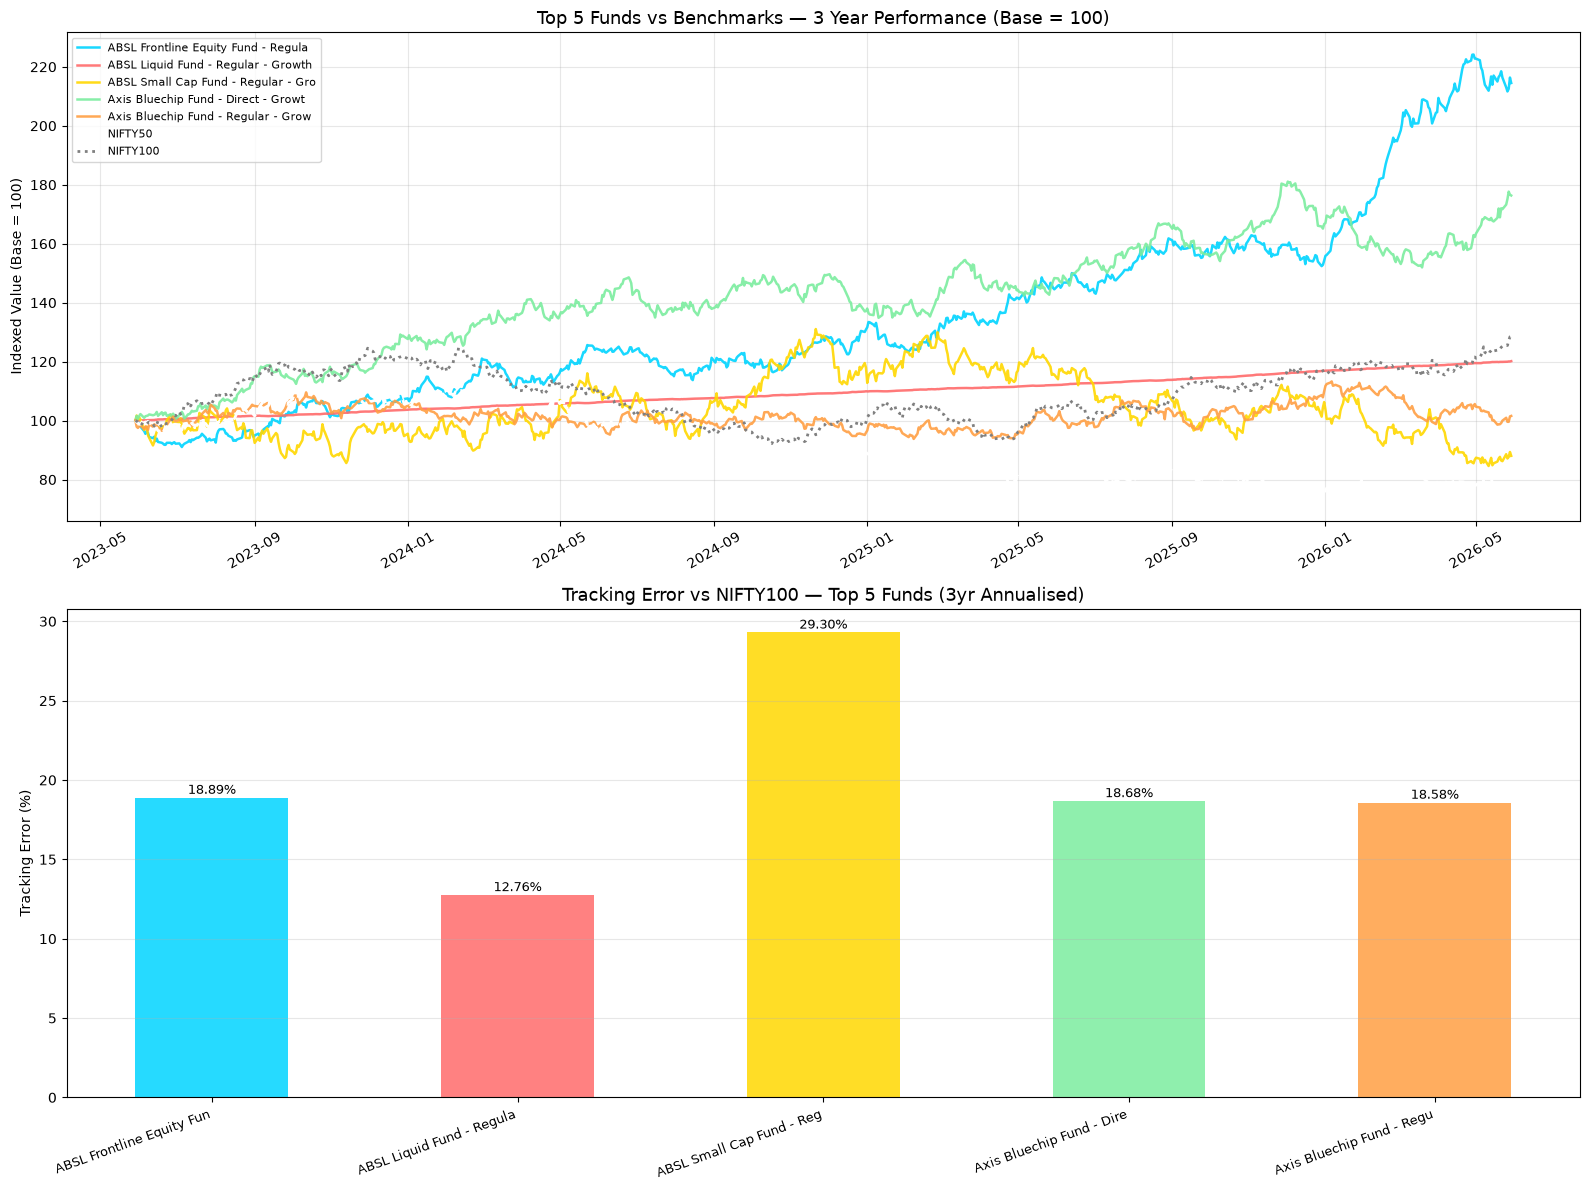


📊 Tracking Error Summary (vs NIFTY100, 3yr annualised):
  ABSL Frontline Equity Fun      18.89%
  ABSL Liquid Fund - Regula      12.76%
  ABSL Small Cap Fund - Reg      29.30%
  Axis Bluechip Fund - Dire      18.68%
  Axis Bluechip Fund - Regu      18.58%

✅ Chart saved to reports folder


In [22]:
# ── Task 8 — Benchmark Comparison Chart + Tracking Error ──────────────────────

top5 = scorecard.head(5).index.tolist()
cutoff_3yr = end_date - pd.DateOffset(years=3)

# Correct index names matching your actual data
nifty50 = bench_df[bench_df["index_name"] == "NIFTY50"]\
          .set_index("date")["close_value"].sort_index()
nifty100_nav = bench_df[bench_df["index_name"] == "NIFTY100"]\
               .set_index("date")["close_value"].sort_index()

# Make sure dates are datetime
nifty50.index     = pd.to_datetime(nifty50.index)
nifty100_nav.index = pd.to_datetime(nifty100_nav.index)

def rebase(series, cutoff):
    s = series.loc[series.index >= pd.Timestamp(cutoff)].dropna()
    if len(s) == 0:
        return s
    return s / s.iloc[0] * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
colors = ["#00d4ff", "#ff6b6b", "#ffd700", "#7bed9f", "#ff9f43"]

# ── Panel 1 — NAV lines rebased to 100 ────────────────────────────────────────
ax1 = axes[0]

for i, f in enumerate(top5):
    s = rebase(nav_wide[f], cutoff_3yr)
    if len(s) == 0:
        continue
    ax1.plot(s.index, s.values, color=colors[i], lw=1.8,
             label=f[:35], alpha=0.9)

rb50  = rebase(nifty50, cutoff_3yr)
rb100 = rebase(nifty100_nav, cutoff_3yr)

if len(rb50) > 0:
    ax1.plot(rb50.index, rb50.values,
             color="white", lw=2, ls="--", label="NIFTY50")

if len(rb100) > 0:
    ax1.plot(rb100.index, rb100.values,
             color="gray", lw=2, ls=":", label="NIFTY100")

ax1.set_title("Top 5 Funds vs Benchmarks — 3 Year Performance (Base = 100)",
              fontsize=13)
ax1.set_ylabel("Indexed Value (Base = 100)")
ax1.legend(fontsize=8, loc="upper left")
ax1.grid(alpha=0.3)
ax1.tick_params(axis="x", rotation=30)

# ── Panel 2 — Tracking Error bars ─────────────────────────────────────────────
ax2 = axes[1]

bench100_ret = nifty100_nav.pct_change().dropna()
te_vals, te_labs = [], []

for f in top5:
    fr = daily_ret[f].dropna()
    fr.index = pd.to_datetime(fr.index)
    idx = fr.index.intersection(bench100_ret.index)
    c3  = [d for d in idx if d >= pd.Timestamp(cutoff_3yr)]
    if len(c3) < 10:
        te_vals.append(0)
    else:
        te = (fr.loc[c3] - bench100_ret.loc[c3]).std() * np.sqrt(252) * 100
        te_vals.append(round(te, 2))
    te_labs.append(f[:25])

bars = ax2.bar(range(len(te_labs)), te_vals,
               color=colors[:len(te_labs)], alpha=0.85, width=0.5)
ax2.set_xticks(range(len(te_labs)))
ax2.set_xticklabels(te_labs, rotation=20, ha="right", fontsize=9)
ax2.set_title("Tracking Error vs NIFTY100 — Top 5 Funds (3yr Annualised)",
              fontsize=13)
ax2.set_ylabel("Tracking Error (%)")
ax2.grid(axis="y", alpha=0.3)

for i, v in enumerate(te_vals):
    ax2.text(i, v + 0.05, f"{v:.2f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()

# Save to reports folder
plt.savefig(
    r"C:\Users\ASUS\Desktop\Mutual Fund Analytics\reports\benchmark_comparison.png",
    dpi=150, bbox_inches="tight"
)
plt.show()

# Print tracking error summary
print("\n📊 Tracking Error Summary (vs NIFTY100, 3yr annualised):")
for lab, tv in zip(te_labs, te_vals):
    print(f"  {lab:<30} {tv:.2f}%")

print("\n✅ Chart saved to reports folder")

In [21]:
print("Benchmark date range:")
print(bench_df["date"].min(), "to", bench_df["date"].max())

print("\nIndex names in your data:")
print(bench_df["index_name"].unique())

print("\ncutoff_3yr:", cutoff_3yr)

print("\nNifty50 rows after cutoff:", len(nifty50[nifty50.index >= pd.Timestamp(cutoff_3yr)]))
print("Nifty100 rows after cutoff:", len(nifty100_nav[nifty100_nav.index >= pd.Timestamp(cutoff_3yr)]))

Benchmark date range:
2022-01-03 00:00:00 to 2026-05-29 00:00:00

Index names in your data:
<StringArray>
[   'BSE_SMALLCAP',     'CRISIL_GILT',   'CRISIL_LIQUID',        'NIFTY100',
         'NIFTY50',        'NIFTY500', 'NIFTY_MIDCAP150']
Length: 7, dtype: str

cutoff_3yr: 2023-05-29 00:00:00

Nifty50 rows after cutoff: 0
Nifty100 rows after cutoff: 0
